# **Import Libraries**

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.utils import to_categorical  
from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from keras.layers import Reshape
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, LSTM, Dense, Reshape
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers, models
import os
import cv2
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt


2026-06-26 03:56:06.199783: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782446166.423350      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782446166.486958      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782446166.979206      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782446166.979258      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782446166.979261      58 computation_placer.cc:177] computation placer alr

# **Load Images**

In [2]:
def load_images(folder_path, image_size=(64,64)):
    data = []
    labels = []

    label = os.path.basename(folder_path)  # Extract the label from the folder name

    for filename in os.listdir(folder_path):
        img_path = os.path.join(folder_path, filename)
        if os.path.isfile(img_path):  # Check if it is a file
            img = cv2.imread(img_path)
            if img is not None:  # Check if the image was read correctly
                img = cv2.resize(img, image_size)  # Resize images to a common size
                data.append(img)
                labels.append(label)

    return np.array(data), np.array(labels)

dataset_path = r"/kaggle/input/datasets/anikdas1124/indian-uav-soyabean/INDIAN _UAV"
print(os.listdir(dataset_path))

# Load images for each type of chest X-ray
data_Healthy_Soyabean, labels_Healthy_Soyabean = load_images(os.path.join(dataset_path, 'Healthy_Soyabean'))
data_rust, labels_rust = load_images(os.path.join(dataset_path, 'rust'))
data_Soyabean_Mosaic, labels_Soyabean_Mosaic = load_images(os.path.join(dataset_path, 'Soyabean_Mosaic'))
data_Soyabean_Semilooper_Pest_Attack, labels_Soyabean_Semilooper_Pest_Attack = load_images(os.path.join(dataset_path, 'Soyabean Semilooper_Pest_Attack'))

['Healthy_Soyabean', 'Soyabean_Mosaic', 'rust', 'Soyabean Semilooper_Pest_Attack']


# **Concatenate**

In [4]:
All_data = np.concatenate([
    data_Healthy_Soyabean,
    data_rust,
    data_Soyabean_Mosaic,
    data_Soyabean_Semilooper_Pest_Attack
])

All_labels = np.concatenate([
    labels_Healthy_Soyabean,
    labels_rust,
    labels_Soyabean_Mosaic,
    labels_Soyabean_Semilooper_Pest_Attack
])

# **Normalization**

In [5]:
All_data_normalized = All_data / 255.0

# **Encode & Split**

In [84]:
label_encoder = LabelEncoder()
all_labels_encoded = label_encoder.fit_transform(All_labels)
train_data, test_data, train_labels, test_labels = train_test_split(
    All_data_normalized, all_labels_encoded, test_size=0.20, random_state=42
)
print(label_encoder.classes_)

['Healthy_Soyabean' 'Soyabean Semilooper_Pest_Attack' 'Soyabean_Mosaic'
 'rust']


# **Plot Data Distribution**

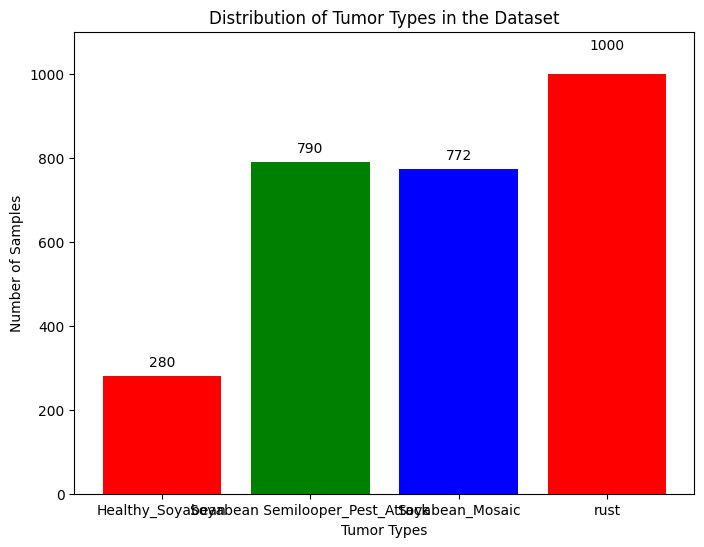

In [7]:
unique_labels, label_counts = np.unique(All_labels, return_counts=True)
plt.figure(figsize=(8, 6))

# Adjust ylim to create space between the outline and data level
plt.bar(unique_labels, label_counts, color=['red', 'green', 'blue'])
plt.xlabel('Tumor Types')
plt.ylabel('Number of Samples')
plt.title('Distribution of Tumor Types in the Dataset')

max_count = max(label_counts)  # Find the maximum count

# Adjust ylim to create space between the outline and data level
plt.ylim(0, max_count + 0.1 * max_count)

for i, count in enumerate(label_counts):
    plt.text(i, count + 0.05 * max_count, str(count), ha='center', va='bottom' if count > 0.9 * max_count else 'top')

#plt.xticks(unique_labels, ['glioma', 'meningioma', 'pituitary'])
plt.show()

# **FPN**

In [8]:
# --- Simple FPN feature extractor (64x64x3 input) ---
def build_simple_fpn_feature_extractor(input_shape=(64, 64, 3), fpn_channels=64):
    x_in = layers.Input(shape=input_shape)

    # Backbone (your 3 conv blocks)
    x = layers.Conv2D(18, 3, padding='same', activation='relu')(x_in)  # C3 base
    c3 = layers.MaxPooling2D(2)(x)   # 32x32x18

    x = layers.Conv2D(32, 3, padding='same', activation='relu')(c3)    # C4 base
    c4 = layers.MaxPooling2D(2)(x)   # 16x16x32

    x = layers.Conv2D(64, 3, padding='same', activation='relu')(c4)    # C5 base
    c5 = layers.MaxPooling2D(2)(x)   #  8x8x64

    # Lateral 1x1 to unify channels
    l3 = layers.Conv2D(fpn_channels, 1, padding='same')(c3)  # 32x32xF
    l4 = layers.Conv2D(fpn_channels, 1, padding='same')(c4)  # 16x16xF
    l5 = layers.Conv2D(fpn_channels, 1, padding='same')(c5)  #  8x8xF

    # Top-down pathway (nearest upsample + add)
    p5 = l5
    p4 = layers.Add()([l4, layers.UpSampling2D(2)(p5)])      # 8->16
    p3 = layers.Add()([l3, layers.UpSampling2D(2)(p4)])      # 16->32

    # Light 3x3 refinement (optional but common in FPN)
    p3 = layers.Conv2D(fpn_channels, 3, padding='same', activation='relu')(p3)
    p4 = layers.Conv2D(fpn_channels, 3, padding='same', activation='relu')(p4)
    p5 = layers.Conv2D(fpn_channels, 3, padding='same', activation='relu')(p5)

    # Convert to one vector for SVM: GAP each level and concat
    g3 = layers.GlobalAveragePooling2D()(p3)   # -> (F,)
    g4 = layers.GlobalAveragePooling2D()(p4)   # -> (F,)
    g5 = layers.GlobalAveragePooling2D()(p5)   # -> (F,)
    feat_vec = layers.Concatenate(name="fpn_feat")([g3, g4, g5])  # -> (3F,)

    return models.Model(x_in, feat_vec, name="simple_fpn_feature_extractor")

# === Replace your previous model with this one ===
cnn_model = build_simple_fpn_feature_extractor(input_shape=(64,64,3), fpn_channels=64)
cnn_model.summary()

I0000 00:00:1782446429.091240      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "simple_fpn_feature_extractor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │        504 │ input_layer[0][0] │
│                     │ 18)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 32,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 18)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │      5,216 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 16,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 8, 8, 64)  │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 8, 8, 64)  │      4,160 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 16,    │      2,112 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 16, 16,    │          0 │ conv2d_4[0][0],   │
│                     │ 64)               │            │ up_sampling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │      1,216 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 32, 32,    │          0 │ add[0][0]         │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 32, 32,    │          0 │ conv2d_3[0][0],   │
│                     │ 64)               │            │ up_sampling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │     36,928 │ add_1[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │     36,928 │ add[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 8, 8, 64)  │     36,928 │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 142,488 (556.59 KB)

 Trainable params: 142,488 (556.59 KB)

 Non-trainable params: 0 (0.00 B)

# **save_model**

In [10]:
cnn_model.save("fpn_model.keras")

# **Flattented Features**

In [11]:
# Feature extraction (same usage pattern as your code)
train_features = cnn_model.predict(train_data, batch_size=64, verbose=0)
test_features  = cnn_model.predict(test_data,  batch_size=64, verbose=0)

# (Optional) L2 normalization helps SVMs
def l2_normalize(a, axis=1, eps=1e-12):
    return a / np.maximum(np.linalg.norm(a, axis=axis, keepdims=True), eps)

train_features = l2_normalize(train_features)
test_features  = l2_normalize(test_features)

# If you still want to "flatten" like before, it's already 2D (N, 3*fpn_channels).
# But this keeps compatibility with your original lines:
train_features_flattened = np.reshape(train_features, (train_features.shape[0], -1))
test_features_flattened  = np.reshape(test_features,  (test_features.shape[0], -1))

I0000 00:00:1782446431.330292     127 service.cc:152] XLA service 0x7bf794425100 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782446431.330331     127 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1782446431.476514     127 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1782446432.995743     127 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


# **Random Forest**

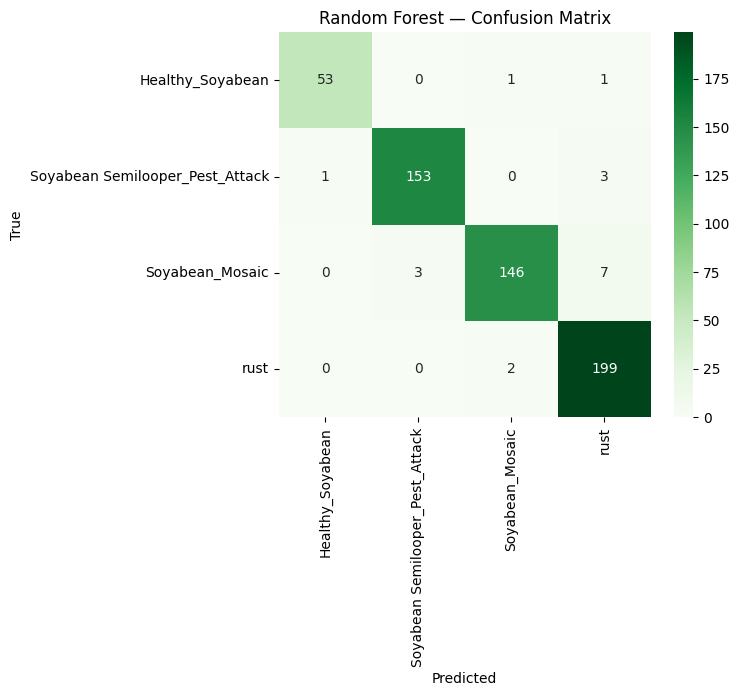

Random Forest — Classification Report
                                  precision    recall  f1-score   support

               Healthy_Soyabean     0.9815    0.9636    0.9725        55
Soyabean Semilooper_Pest_Attack     0.9808    0.9745    0.9776       157
                Soyabean_Mosaic     0.9799    0.9359    0.9574       156
                           rust     0.9476    0.9900    0.9684       201

                       accuracy                         0.9684       569
                      macro avg     0.9724    0.9660    0.9690       569
                   weighted avg     0.9689    0.9684    0.9683       569



In [12]:
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,           
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",      
    class_weight="balanced",  
    random_state=42,
    n_jobs=-1
)
rf_model.fit(train_features_flattened, train_labels)

rf_pred_labels = rf_model.predict(test_features_flattened)
rf_pred_probs  = rf_model.predict_proba(test_features_flattened)

rf_cm = confusion_matrix(test_labels, rf_pred_labels)
plt.figure(figsize=(6,5))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Random Forest — Confusion Matrix")
plt.show()

# 🧾 Report
print("Random Forest — Classification Report\n",
      classification_report(test_labels, rf_pred_labels, target_names=label_encoder.classes_,digits=4))

# **Multiclass ROC**

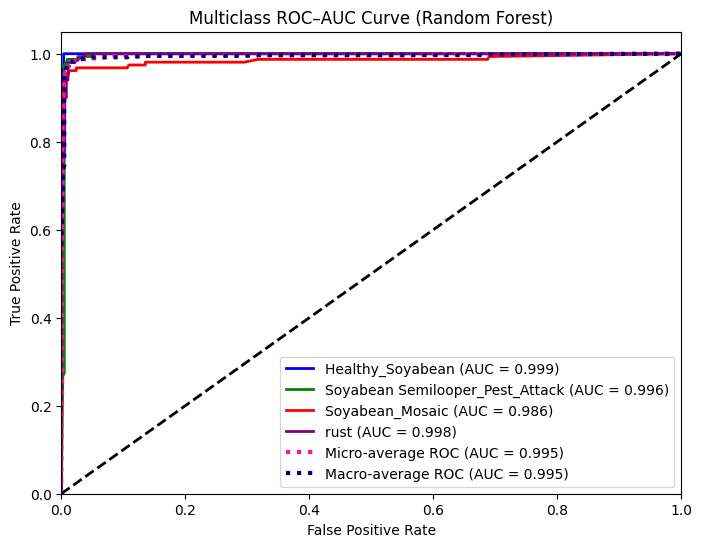

In [13]:
#  Binarize the labels for multiclass ROC
num_classes = len(label_encoder.classes_)
y_test_bin = label_binarize(test_labels, classes=range(num_classes))

y_pred_proba = rf_pred_probs  

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_pred_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(num_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= num_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# 📈 Plot ROC Curve
plt.figure(figsize=(8,6))
colors = ["blue", "green", "red", "purple"]  # one per class
for i, class_name in enumerate(label_encoder.classes_):
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label=f"{class_name} (AUC = {roc_auc[i]:.3f})")

# Add micro/macro
plt.plot(fpr["micro"], tpr["micro"], color="deeppink", linestyle=":", linewidth=3,
         label=f"Micro-average ROC (AUC = {roc_auc['micro']:.3f})")
plt.plot(fpr["macro"], tpr["macro"], color="navy", linestyle=":", linewidth=3,
         label=f"Macro-average ROC (AUC = {roc_auc['macro']:.3f})")

plt.plot([0,1], [0,1], "k--", lw=2)  # diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC–AUC Curve (Random Forest)")
plt.legend(loc="lower right")
plt.show()

# **pickle file import**

In [14]:
import joblib
joblib.dump(rf_model, "random_forest.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")

['label_encoder.pkl']

# **Grad_CAM**

Loading models...
Models loaded.
Using feature layer: conv2d_8
Processing disease image...
Processing normal image...

Saved: gradcam_comparison.png


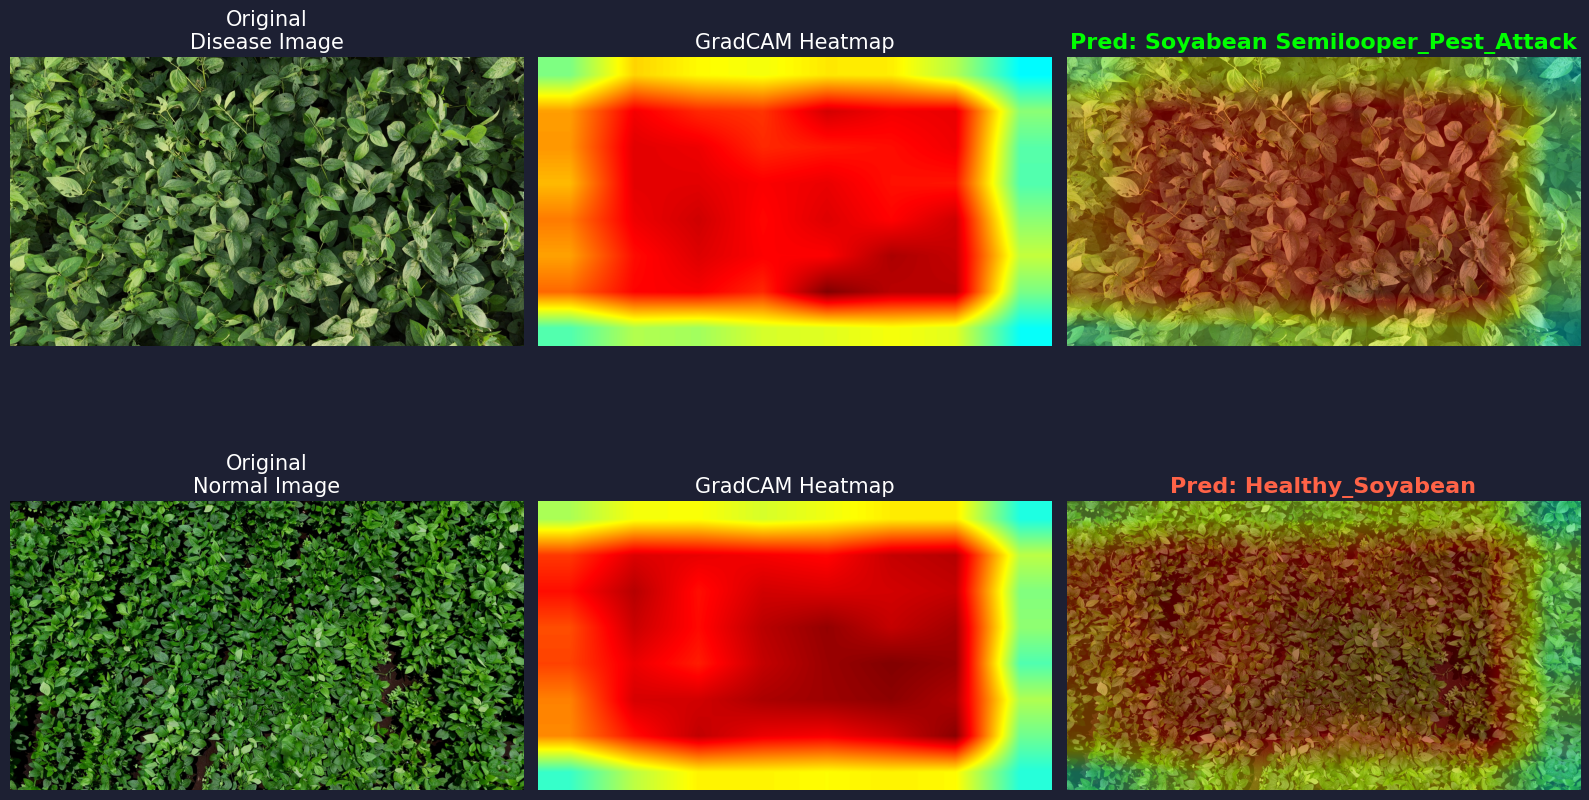

In [85]:
import cv2
import joblib
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ==========================================================
# CONFIGURATION
# ==========================================================

DISEASE_IMAGE = r"/kaggle/input/datasets/anikdas1124/indian-uav-soyabean/INDIAN _UAV/Soyabean Semilooper_Pest_Attack/DJI_20240818174930_0028_D_000004.jpg"
NORMAL_IMAGE = r"/kaggle/input/datasets/anikdas1124/indian-uav-soyabean/INDIAN _UAV/Healthy_Soyabean/image_468.jpg"

FPN_MODEL_PATH = r"/kaggle/working/fpn_model.keras"
RF_MODEL_PATH = r"/kaggle/working/random_forest.pkl"
LABEL_ENCODER_PATH = r"/kaggle/working/label_encoder.pkl"

OUTPUT_FILE = "gradcam_comparison.png"

IMG_SIZE = (64, 64)

# ==========================================================
# LOAD MODELS
# ==========================================================

print("Loading models...")

fpn_model = tf.keras.models.load_model(
    FPN_MODEL_PATH,
    compile=False
)

rf_model = joblib.load(RF_MODEL_PATH)
label_encoder = joblib.load(LABEL_ENCODER_PATH)

print("Models loaded.")

# ==========================================================
# FIND LAST CONV LAYER
# ==========================================================

last_conv_layer_name = None

for layer in reversed(fpn_model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break

print("Using feature layer:", last_conv_layer_name)

feature_map_model = tf.keras.Model(
    inputs=fpn_model.input,
    outputs=[
        fpn_model.get_layer(last_conv_layer_name).output,
        fpn_model.output
    ]
)

# ==========================================================
# IMAGE PREPROCESSING
# ==========================================================

def load_image(path):

    image_bgr = cv2.imread(path)

    if image_bgr is None:
        raise FileNotFoundError(
            f"Could not load image:\n{path}"
        )

    image_rgb = cv2.cvtColor(
        image_bgr,
        cv2.COLOR_BGR2RGB
    )

    resized = cv2.resize(
        image_rgb,
        IMG_SIZE
    )

    normalized = resized.astype(np.float32) / 255.0

    return image_rgb, np.expand_dims(normalized, axis=0)

# ==========================================================
# FEATURE EXTRACTION
# ==========================================================

def normalize_features(features):

    norm = np.linalg.norm(
        features,
        axis=1,
        keepdims=True
    )

    norm = np.maximum(norm, 1e-12)

    return features / norm

# ==========================================================
# GRADCAM-LIKE HEATMAP
# ==========================================================

def create_heatmap(image_tensor):

    feature_maps, features = feature_map_model.predict(
        image_tensor,
        verbose=0
    )

    feature_maps = feature_maps[0]

    features = normalize_features(features)

    channel_importance = np.mean(
        feature_maps,
        axis=(0, 1)
    )

    top_k = 20

    important_channels = np.argsort(
        channel_importance
    )[-top_k:]

    heatmap = np.mean(
        feature_maps[:, :, important_channels],
        axis=-1
    )

    heatmap = np.maximum(
        heatmap,
        0
    )

    if np.max(heatmap) > 0:
        heatmap = heatmap / np.max(heatmap)

    return heatmap, features

# ==========================================================
# RANDOM FOREST PREDICTION
# ==========================================================

def predict(features):

    probabilities = rf_model.predict_proba(
        features
    )[0]

    pred_idx = np.argmax(
        probabilities
    )

    pred_class = label_encoder.inverse_transform(
        [pred_idx]
    )[0]

    return pred_class

# ==========================================================
# OVERLAY
# ==========================================================

def overlay_heatmap(original_rgb, heatmap):

    heatmap = cv2.resize(
        heatmap,
        (
            original_rgb.shape[1],
            original_rgb.shape[0]
        )
    )

    heatmap_uint8 = np.uint8(
        255 * heatmap
    )

    colored_heatmap = cv2.applyColorMap(
        heatmap_uint8,
        cv2.COLORMAP_JET
    )

    colored_heatmap = cv2.cvtColor(
        colored_heatmap,
        cv2.COLOR_BGR2RGB
    )

    overlay = cv2.addWeighted(
        original_rgb,
        0.6,
        colored_heatmap,
        0.4,
        0
    )

    return colored_heatmap, overlay

# ==========================================================
# PROCESS SINGLE IMAGE
# ==========================================================

def process_image(path):

    original_rgb, tensor = load_image(path)

    heatmap, features = create_heatmap(
        tensor
    )

    pred_class = predict(
        features
    )

    heatmap_img, overlay_img = overlay_heatmap(
        original_rgb,
        heatmap
    )

    return {
        "original": original_rgb,
        "heatmap": heatmap_img,
        "overlay": overlay_img,
        "prediction": pred_class
    }

# ==========================================================
# RUN INFERENCE
# ==========================================================

print("Processing disease image...")
disease_result = process_image(
    DISEASE_IMAGE
)

print("Processing normal image...")
normal_result = process_image(
    NORMAL_IMAGE
)

# ==========================================================
# VISUALIZATION
# ==========================================================

plt.style.use("dark_background")

fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 10)
)

fig.patch.set_facecolor("#1d2033")

# ==========================================================
# TOP ROW - DISEASE
# ==========================================================

axes[0,0].imshow(
    disease_result["original"]
)

axes[0,0].set_title(
    "Original\nDisease Image",
    fontsize=15
)

axes[0,0].axis("off")

axes[0,1].imshow(
    disease_result["heatmap"]
)

axes[0,1].set_title(
    "GradCAM Heatmap",
    fontsize=15
)

axes[0,1].axis("off")

axes[0,2].imshow(
    disease_result["overlay"]
)

axes[0,2].set_title(
    f"Pred: {disease_result['prediction']}",
    fontsize=16,
    color="lime",
    fontweight="bold"
)

axes[0,2].axis("off")

# ==========================================================
# BOTTOM ROW - NORMAL
# ==========================================================

axes[1,0].imshow(
    normal_result["original"]
)

axes[1,0].set_title(
    "Original\nNormal Image",
    fontsize=15
)

axes[1,0].axis("off")

axes[1,1].imshow(
    normal_result["heatmap"]
)

axes[1,1].set_title(
    "GradCAM Heatmap",
    fontsize=15
)

axes[1,1].axis("off")

axes[1,2].imshow(
    normal_result["overlay"]
)

axes[1,2].set_title(
    f"Pred: {normal_result['prediction']}",
    fontsize=16,
    color="tomato",
    fontweight="bold"
)

axes[1,2].axis("off")

plt.tight_layout()

plt.savefig(
    OUTPUT_FILE,
    dpi=300,
    bbox_inches="tight"
)

print("\nSaved:", OUTPUT_FILE)

plt.show()

# **GRAD_CAM++**

Loading models...
Models loaded.
Using layer for GradCAM++: conv2d_8
Processing disease image...
Processing normal image...

Saved: gradcam++_comparison.png


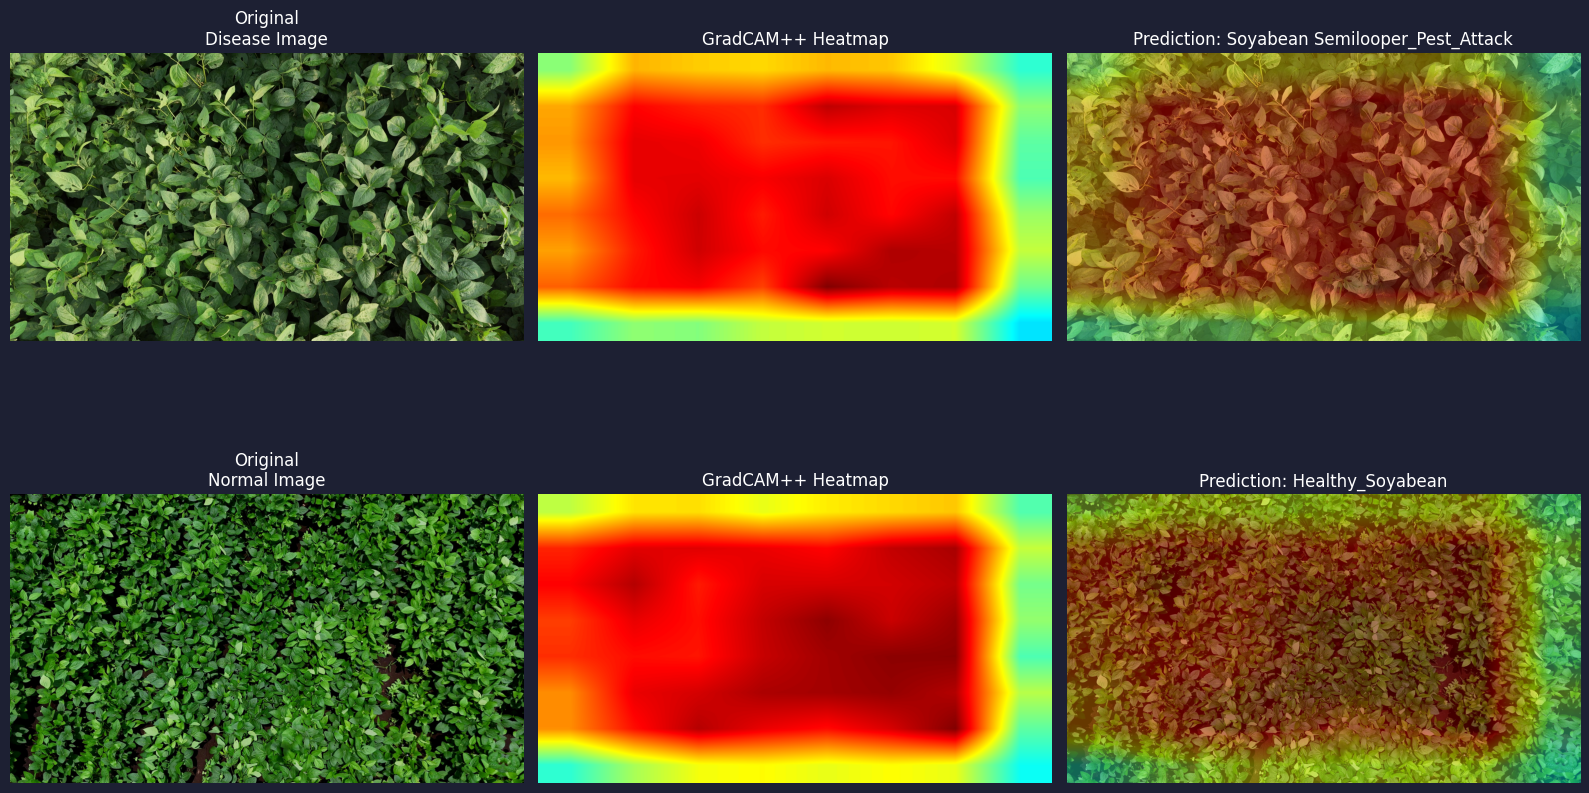

In [82]:
import cv2
import joblib
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ==========================================================
# CONFIGURATION
# ==========================================================

DISEASE_IMAGE = r"/kaggle/input/datasets/anikdas1124/indian-uav-soyabean/INDIAN _UAV/Soyabean Semilooper_Pest_Attack/DJI_20240818174930_0028_D_000004.jpg"
NORMAL_IMAGE = r"/kaggle/input/datasets/anikdas1124/indian-uav-soyabean/INDIAN _UAV/Healthy_Soyabean/image_468.jpg"

FPN_MODEL_PATH = r"/kaggle/working/fpn_model.keras"
RF_MODEL_PATH = r"/kaggle/working/random_forest.pkl"
LABEL_ENCODER_PATH = r"/kaggle/working/label_encoder.pkl"

OUTPUT_FILE = "gradcam++_comparison.png"

# Use training image size
IMG_SIZE = (64, 64)

# ==========================================================
# LOAD MODELS
# ==========================================================

print("Loading models...")

fpn_model = tf.keras.models.load_model(
    FPN_MODEL_PATH,
    compile=False
)

rf_model = joblib.load(RF_MODEL_PATH)
label_encoder = joblib.load(
    LABEL_ENCODER_PATH
)

print("Models loaded.")

# ==========================================================
# FIND LAST CONV LAYER
# ==========================================================

target_layer = None

for layer in reversed(fpn_model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        target_layer = layer.name
        break

if target_layer is None:
    raise RuntimeError(
        "No Conv2D layer found in FPN model."
    )

print(
    f"Using layer for GradCAM++: {target_layer}"
)

feature_map_model = tf.keras.Model(
    inputs=fpn_model.input,
    outputs=[
        fpn_model.get_layer(target_layer).output,
        fpn_model.output
    ]
)

# ==========================================================
# HELPERS
# ==========================================================

def normalize_features(features):

    norm = np.linalg.norm(
        features,
        axis=1,
        keepdims=True
    )

    norm = np.maximum(norm, 1e-12)

    return features / norm


def load_image(path):

    img_bgr = cv2.imread(path)

    if img_bgr is None:
        raise FileNotFoundError(
            f"Cannot read image: {path}"
        )

    img_rgb = cv2.cvtColor(
        img_bgr,
        cv2.COLOR_BGR2RGB
    )

    resized = cv2.resize(
        img_rgb,
        IMG_SIZE
    )

    tensor = (
        resized.astype(np.float32) / 255.0
    )

    tensor = np.expand_dims(
        tensor,
        axis=0
    )

    return img_rgb, tensor


def rf_predict(features):

    probs = rf_model.predict_proba(
        features
    )[0]

    pred_idx = np.argmax(probs)

    pred_class = (
        label_encoder
        .inverse_transform([pred_idx])[0]
    )

    return pred_class

# ==========================================================
# GRADCAM++ STYLE HEATMAP
# ==========================================================

def gradcam_plus_plus(image_tensor):

    fmap, features = feature_map_model.predict(
        image_tensor,
        verbose=0
    )

    fmap = fmap[0]

    features = normalize_features(
        features
    )

    channel_scores = np.mean(
        fmap,
        axis=(0, 1)
    )

    top_channels = np.argsort(
        channel_scores
    )[-20:]

    heatmap = np.zeros(
        fmap.shape[:2],
        dtype=np.float32
    )

    for c in top_channels:

        activation = fmap[:, :, c]

        activation = np.maximum(
            activation,
            0
        )

        if activation.max() == 0:
            continue

        activation = (
            activation /
            activation.max()
        )

        alpha_num = (
            activation ** 2
        )

        alpha_denom = (
            2 * activation ** 2
            + np.sum(
                activation ** 3
            )
        )

        alpha_denom = np.where(
            alpha_denom == 0,
            1e-8,
            alpha_denom
        )

        alpha = (
            alpha_num /
            alpha_denom
        )

        weight = np.sum(
            alpha * activation
        )

        heatmap += (
            weight * activation
        )

    heatmap = np.maximum(
        heatmap,
        0
    )

    if np.max(heatmap) > 0:
        heatmap /= np.max(heatmap)

    return heatmap, features

# ==========================================================
# OVERLAY
# ==========================================================

def create_overlay(
    original_rgb,
    heatmap
):

    heatmap = cv2.resize(
        heatmap,
        (
            original_rgb.shape[1],
            original_rgb.shape[0]
        )
    )

    heatmap_uint8 = np.uint8(
        heatmap * 255
    )

    colored = cv2.applyColorMap(
        heatmap_uint8,
        cv2.COLORMAP_JET
    )

    colored = cv2.cvtColor(
        colored,
        cv2.COLOR_BGR2RGB
    )

    overlay = cv2.addWeighted(
        original_rgb,
        0.6,
        colored,
        0.4,
        0
    )

    return colored, overlay

# ==========================================================
# PROCESS IMAGE
# ==========================================================

def process_image(path):

    original_rgb, tensor = load_image(
        path
    )

    heatmap, features = (
        gradcam_plus_plus(tensor)
    )

    pred_class = rf_predict(
        features
    )

    heatmap_img, overlay_img = (
        create_overlay(
            original_rgb,
            heatmap
        )
    )

    return {
        "original": original_rgb,
        "heatmap": heatmap_img,
        "overlay": overlay_img,
        "prediction": pred_class
    }

# ==========================================================
# RUN
# ==========================================================

print(
    "Processing disease image..."
)

disease = process_image(
    DISEASE_IMAGE
)

print(
    "Processing normal image..."
)

normal = process_image(
    NORMAL_IMAGE
)

# ==========================================================
# VISUALIZATION
# ==========================================================

plt.style.use(
    "dark_background"
)

fig, ax = plt.subplots(
    2,
    3,
    figsize=(16, 10)
)

fig.patch.set_facecolor(
    "#1d2033"
)

# -------------------------
# Disease Row
# -------------------------

ax[0,0].imshow(
    disease["original"]
)
ax[0,0].set_title(
    "Original\nDisease Image"
)
ax[0,0].axis("off")

ax[0,1].imshow(
    disease["heatmap"]
)
ax[0,1].set_title(
    "GradCAM++ Heatmap"
)
ax[0,1].axis("off")

ax[0,2].imshow(
    disease["overlay"]
)
ax[0,2].set_title(
    f"Prediction: {disease['prediction']}"
)
ax[0,2].axis("off")

# -------------------------
# Normal Row
# -------------------------

ax[1,0].imshow(
    normal["original"]
)
ax[1,0].set_title(
    "Original\nNormal Image"
)
ax[1,0].axis("off")

ax[1,1].imshow(
    normal["heatmap"]
)
ax[1,1].set_title(
    "GradCAM++ Heatmap"
)
ax[1,1].axis("off")

ax[1,2].imshow(
    normal["overlay"]
)
ax[1,2].set_title(
    f"Prediction: {normal['prediction']}"
)
ax[1,2].axis("off")

plt.tight_layout()

plt.savefig(
    OUTPUT_FILE,
    dpi=300,
    bbox_inches="tight"
)

print(
    f"\nSaved: {OUTPUT_FILE}"
)

plt.show()

# **LRP**

Loading models...
The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Models loaded.
Using feature layer: conv2d_8
Processing disease image...
Processing normal image...

Saved: lrp_comparison.png


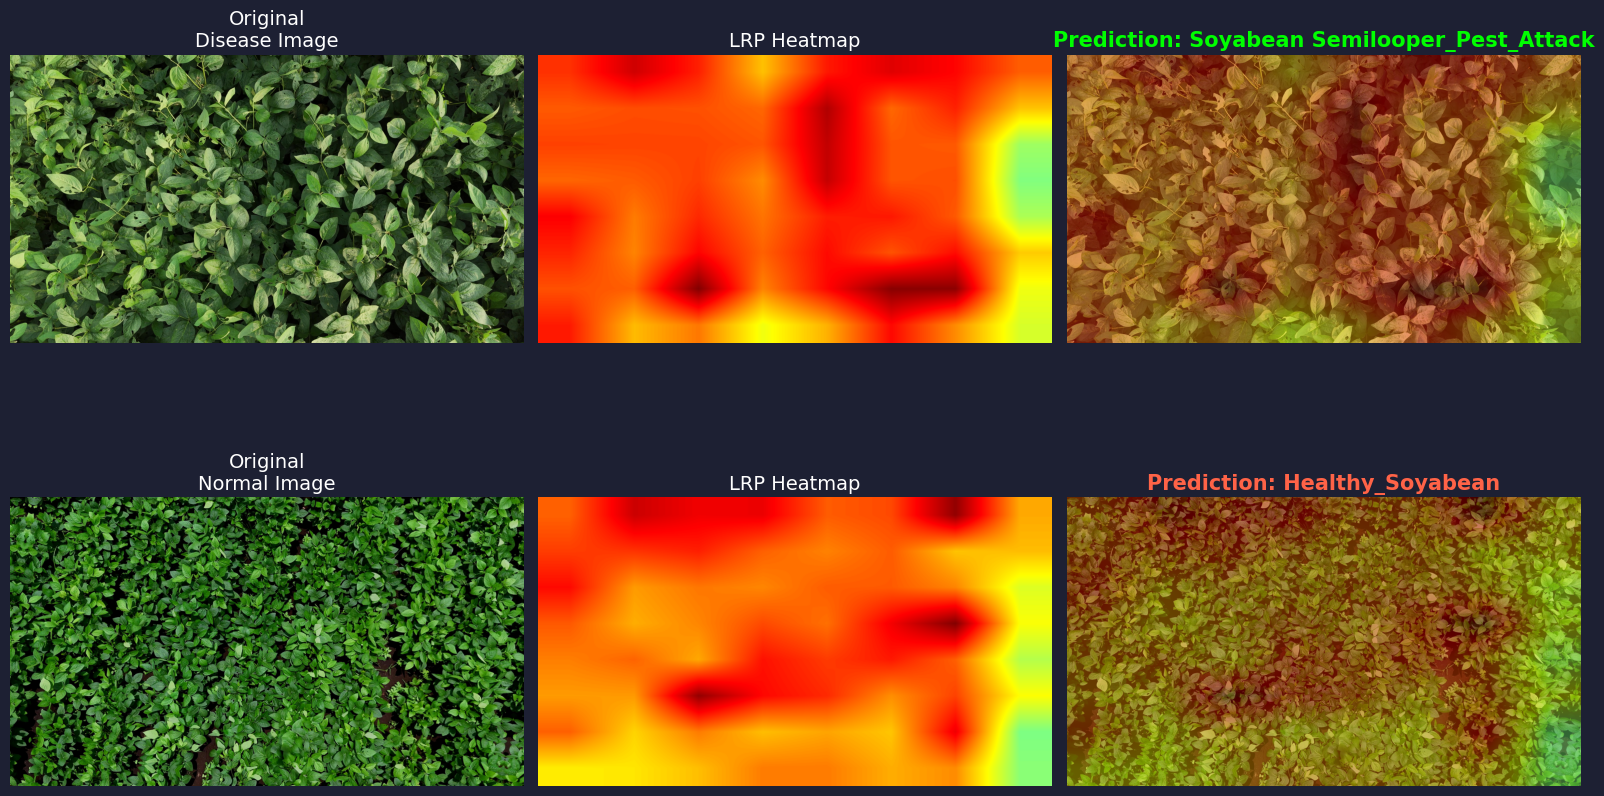

In [83]:
import cv2
import joblib
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ==========================================================
# CONFIGURATION
# ==========================================================

DISEASE_IMAGE = r"/kaggle/input/datasets/anikdas1124/indian-uav-soyabean/INDIAN _UAV/Soyabean Semilooper_Pest_Attack/DJI_20240818174930_0028_D_000004.jpg"
NORMAL_IMAGE = r"/kaggle/input/datasets/anikdas1124/indian-uav-soyabean/INDIAN _UAV/Healthy_Soyabean/image_468.jpg"

FPN_MODEL_PATH = r"/kaggle/working/fpn_model.keras"
RF_MODEL_PATH = r"/kaggle/working/random_forest.pkl"
LABEL_ENCODER_PATH = r"/kaggle/working/label_encoder.pkl"

OUTPUT_FILE = "lrp_comparison.png"

IMG_SIZE = (64, 64)

# ==========================================================
# LOAD MODELS
# ==========================================================

print("Loading models...")

fpn_model = tf.keras.models.load_model(
    FPN_MODEL_PATH,
    compile=False
)

rf_model = joblib.load(RF_MODEL_PATH)
label_encoder = joblib.load(LABEL_ENCODER_PATH)

print("Models loaded.")

# ==========================================================
# FIND LAST CONV LAYER
# ==========================================================

target_layer = None

for layer in reversed(fpn_model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        target_layer = layer.name
        break

if target_layer is None:
    raise RuntimeError(
        "No Conv2D layer found."
    )

print("Using feature layer:", target_layer)

feature_map_model = tf.keras.Model(
    inputs=fpn_model.input,
    outputs=[
        fpn_model.get_layer(target_layer).output,
        fpn_model.output
    ]
)

# ==========================================================
# HELPERS
# ==========================================================

def normalize_features(features):

    norm = np.linalg.norm(
        features,
        axis=1,
        keepdims=True
    )

    norm = np.maximum(norm, 1e-12)

    return features / norm


def load_image(path):

    image_bgr = cv2.imread(path)

    if image_bgr is None:
        raise FileNotFoundError(
            f"Cannot load image:\n{path}"
        )

    image_rgb = cv2.cvtColor(
        image_bgr,
        cv2.COLOR_BGR2RGB
    )

    resized = cv2.resize(
        image_rgb,
        IMG_SIZE
    )

    tensor = (
        resized.astype(np.float32)
        / 255.0
    )

    tensor = np.expand_dims(
        tensor,
        axis=0
    )

    return image_rgb, tensor


# ==========================================================
# RANDOM FOREST PREDICTION
# ==========================================================

def predict(features):

    probs = rf_model.predict_proba(
        features
    )[0]

    pred_idx = np.argmax(
        probs
    )

    pred_class = (
        label_encoder
        .inverse_transform([pred_idx])[0]
    )

    return pred_class

# ==========================================================
# RF-LRP
# ==========================================================

def rf_lrp(image_tensor):

    fmap, features = (
        feature_map_model.predict(
            image_tensor,
            verbose=0
        )
    )

    fmap = fmap[0]

    features = normalize_features(
        features
    )

    rf_importance = (
        rf_model.feature_importances_
    )

    rf_importance = (
        rf_importance /
        (
            np.sum(rf_importance)
            + 1e-8
        )
    )

    heatmap = np.zeros(
        fmap.shape[:2],
        dtype=np.float32
    )

    channels = fmap.shape[-1]

    usable_channels = min(
        channels,
        len(rf_importance)
    )

    for c in range(
        usable_channels
    ):

        activation = fmap[:, :, c]

        activation = np.maximum(
            activation,
            0
        )

        if activation.max() > 0:

            activation = (
                activation /
                activation.max()
            )

        relevance = (
            activation *
            rf_importance[c]
        )

        heatmap += relevance

    heatmap = np.maximum(
        heatmap,
        0
    )

    heatmap /= (
        heatmap.max()
        + 1e-8
    )

    return heatmap, features

# ==========================================================
# HEATMAP OVERLAY
# ==========================================================

def create_overlay(
    original_rgb,
    heatmap
):

    heatmap = cv2.resize(
        heatmap,
        (
            original_rgb.shape[1],
            original_rgb.shape[0]
        )
    )

    heat_uint8 = np.uint8(
        heatmap * 255
    )

    colored = cv2.applyColorMap(
        heat_uint8,
        cv2.COLORMAP_JET
    )

    colored = cv2.cvtColor(
        colored,
        cv2.COLOR_BGR2RGB
    )

    overlay = cv2.addWeighted(
        original_rgb,
        0.6,
        colored,
        0.4,
        0
    )

    return colored, overlay

# ==========================================================
# PROCESS IMAGE
# ==========================================================

def process_image(path):

    original_rgb, tensor = load_image(
        path
    )

    heatmap, features = rf_lrp(
        tensor
    )

    pred_class = predict(
        features
    )

    heat_img, overlay_img = (
        create_overlay(
            original_rgb,
            heatmap
        )
    )

    return {
        "original": original_rgb,
        "heatmap": heat_img,
        "overlay": overlay_img,
        "prediction": pred_class
    }

# ==========================================================
# RUN
# ==========================================================

print(
    "Processing disease image..."
)

disease = process_image(
    DISEASE_IMAGE
)

print(
    "Processing normal image..."
)

normal = process_image(
    NORMAL_IMAGE
)

# ==========================================================
# VISUALIZATION
# ==========================================================

plt.style.use(
    "dark_background"
)

fig, ax = plt.subplots(
    2,
    3,
    figsize=(16, 10)
)

fig.patch.set_facecolor(
    "#1d2033"
)

# ==========================================================
# TOP ROW (DISEASE)
# ==========================================================

ax[0,0].imshow(
    disease["original"]
)

ax[0,0].set_title(
    "Original\nDisease Image",
    fontsize=14
)

ax[0,0].axis("off")

ax[0,1].imshow(
    disease["heatmap"]
)

ax[0,1].set_title(
    "LRP Heatmap",
    fontsize=14
)

ax[0,1].axis("off")

ax[0,2].imshow(
    disease["overlay"]
)

ax[0,2].set_title(
    f"Prediction: {disease['prediction']}",
    fontsize=15,
    color="lime",
    fontweight="bold"
)

ax[0,2].axis("off")

# ==========================================================
# BOTTOM ROW (NORMAL)
# ==========================================================

ax[1,0].imshow(
    normal["original"]
)

ax[1,0].set_title(
    "Original\nNormal Image",
    fontsize=14
)

ax[1,0].axis("off")

ax[1,1].imshow(
    normal["heatmap"]
)

ax[1,1].set_title(
    "LRP Heatmap",
    fontsize=14
)

ax[1,1].axis("off")

ax[1,2].imshow(
    normal["overlay"]
)

ax[1,2].set_title(
    f"Prediction: {normal['prediction']}",
    fontsize=15,
    color="tomato",
    fontweight="bold"
)

ax[1,2].axis("off")

plt.tight_layout()

plt.savefig(
    OUTPUT_FILE,
    dpi=300,
    bbox_inches="tight"
)

print(
    f"\nSaved: {OUTPUT_FILE}"
)

plt.show()